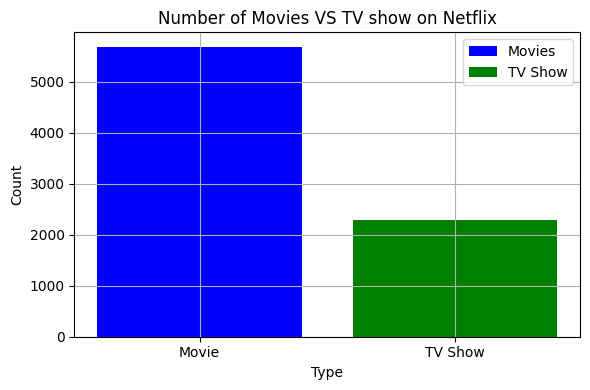

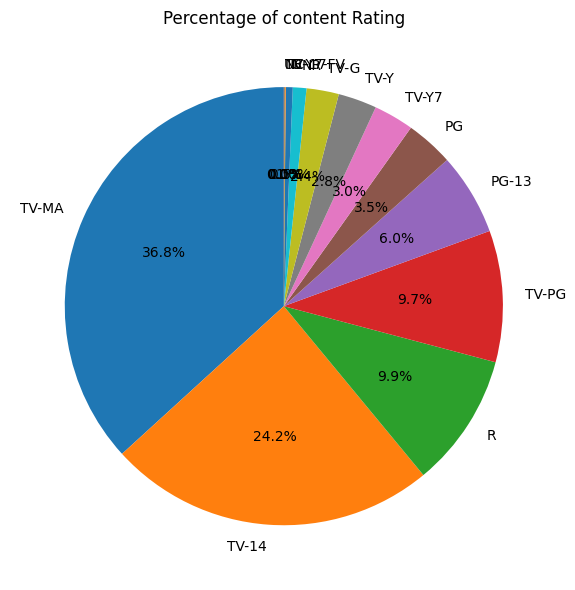

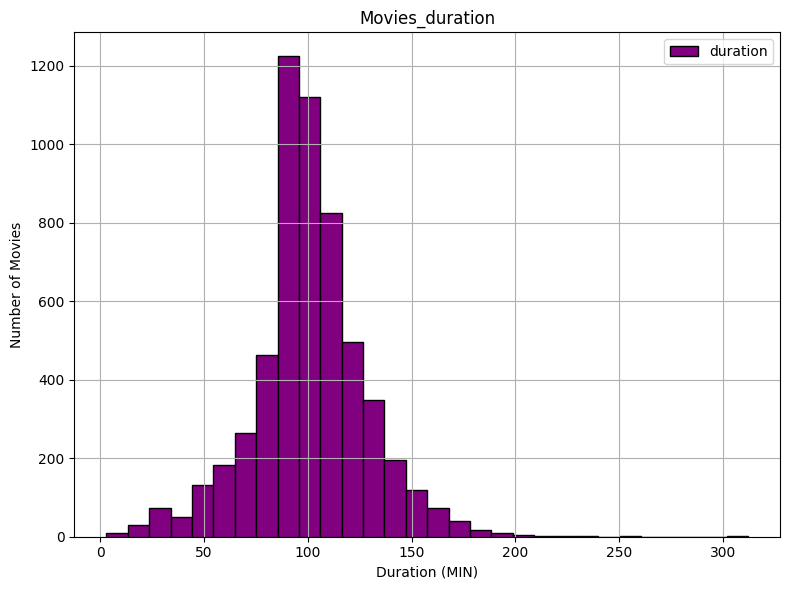

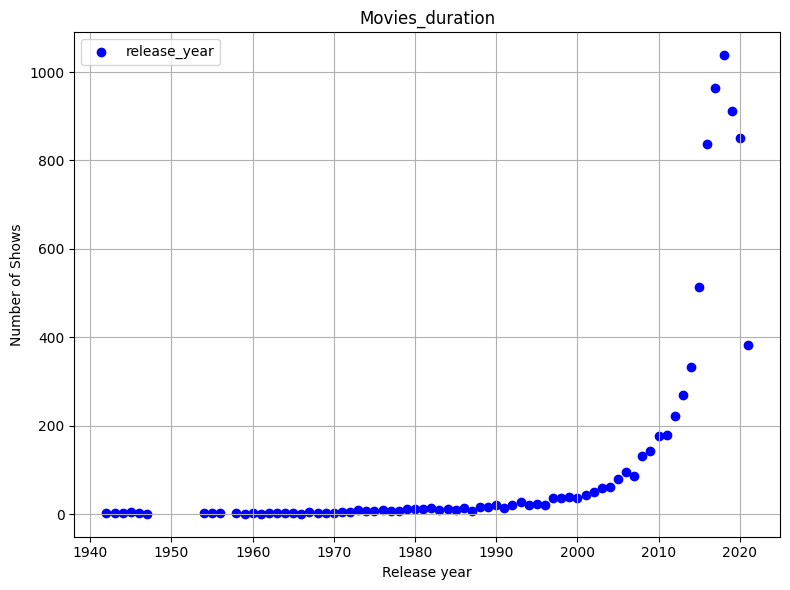

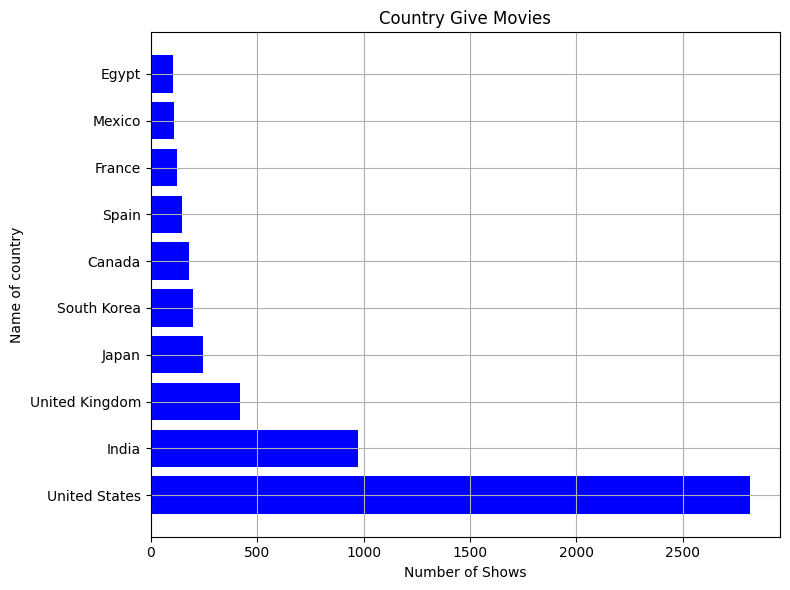

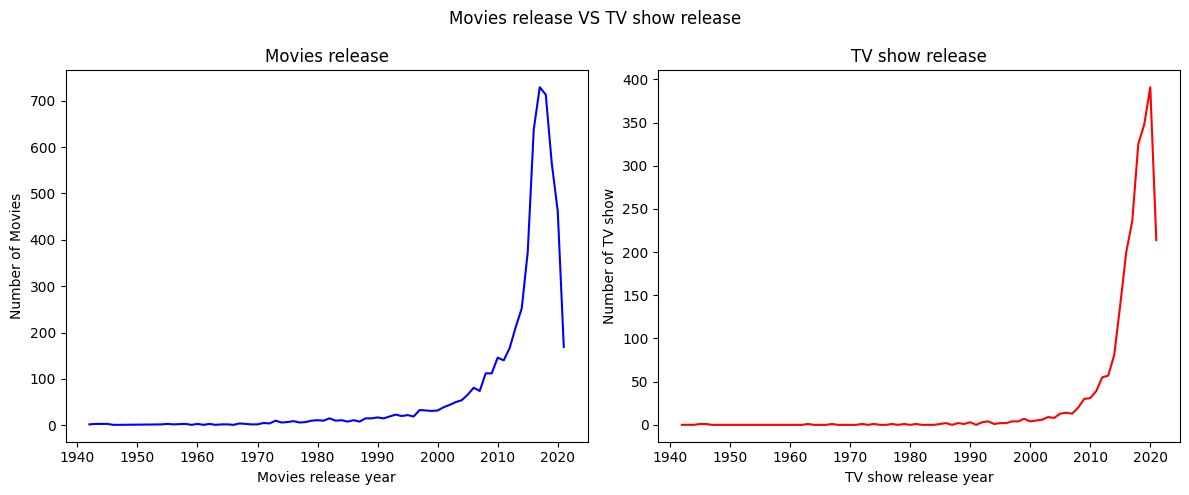

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("netflix_titles.csv",encoding="latin1")
df = df.dropna(subset=["type","release_year","rating","country","duration"])

type_count = df["type"].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_count.index,type_count.values,color = ["blue","green"],label = ["Movies","TV Show"])
plt.xlabel("Type")
plt.ylabel("Count")
plt.title("Number of Movies VS TV show on Netflix")
plt.tight_layout()
plt.legend()
plt.grid()
plt.savefig("netflix_Type_count.png",dpi = 300)
plt.show()

rating_count = df["rating"].value_counts()
plt.figure(figsize=(8,6))
plt.pie(rating_count.values,labels = rating_count.index,autopct="%1.1f%%",startangle=90)
plt.title("Percentage of content Rating")
plt.tight_layout()
plt.savefig("netflix_Rating_count.png",dpi = 300)
plt.show()

movie_df = df[df["type"] == "Movie"].copy()
movie_df["duration_int"] = movie_df["duration"].str.replace("min"," ").astype(int)
plt.figure(figsize=(8,6))
plt.hist(movie_df["duration_int"],bins=30,color="purple",edgecolor = "black",label = "duration")
plt.xlabel("Duration (MIN)")
plt.ylabel("Number of Movies")
plt.title("Movies_duration")
plt.tight_layout()
plt.legend()
plt.grid()
plt.savefig("netflix_Movies_duration.png",dpi = 300)
plt.show()

release_count = df["release_year"].value_counts().sort_index()
plt.figure(figsize=(8,6))
plt.scatter(release_count.index,release_count.values,color = "blue",label = "release_year")
plt.xlabel("Release year")
plt.ylabel("Number of Shows")
plt.title("Movies_duration")
plt.tight_layout()
plt.legend()
plt.grid()
plt.savefig("netflix_release_year.png",dpi = 300)
plt.show()

country_count = df["country"].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(country_count.index,country_count.values,color = "blue")
plt.xlabel("Number of Shows")
plt.ylabel("Name of country")
plt.title("Country Give Movies")
plt.tight_layout()
plt.grid()
plt.savefig("netflix_country.png",dpi = 300)
plt.show()

country_by_year = df.groupby(["release_year","type"]).size().unstack().fillna(0)
fig, ax = plt.subplots(1,2,figsize = (12,5))
ax[0].plot(country_by_year.index,country_by_year["Movie"],color = "blue")
ax[0].set_ylabel("Number of Movies")
ax[0].set_xlabel("Movies release year")
ax[0].set_title("Movies release")
ax[1].plot(country_by_year.index,country_by_year["TV Show"],color = "red")
ax[1].set_ylabel("Number of TV show")
ax[1].set_xlabel("TV show release year")
ax[1].set_title("TV show release")
plt.suptitle("Movies release VS TV show release")
plt.tight_layout()
plt.savefig("Movies release VS TV show release.png",dpi = 300)
plt.show()
